# **Build Custom Object Detector with Detectron2**

<img src="https://dl.fbaipublicfiles.com/detectron2/Detectron2-Logo-Horz.png" width="500">

In [1]:
!pip install 'setuptools<67'

- **INSTALLING ROBOFLOW**

In [2]:
!pip install roboflow

- **INSTALLING DETECTRON2**

In [3]:
!python -m pip install pyyaml==5.1
import sys,os,json,distutils.core

# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
# Remove existing directory if you need to re-run the cell
!rm -rf detectron2
!git clone 'https://github.com/facebookresearch/detectron2'

dist = distutils.core.run_setup('./detectron2/setup.py')
!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0,os.path.abspath('./detectron2'))

  Using cached PyYAML-5.1.tar.gz (274 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 16057, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 16057 (delta 25), reused 8 (delta 8), pack-reused 16016 (from 3)
Receiving objects: 100% (16057/16057), 6.82 MiB | 13.70 MiB/s, done.
Resolving deltas: 100% (11380/11380), done.


In [4]:
import torch,detectron2
!nvcc --version

print(f"\nTORCH_VERSION: {'.'.join(torch.__version__.split('.')[:2])}\nCUDA_VERSION: {torch.__version__.split('+')[-1]}\nDETECTRON_VERSION: {detectron2.__version__}")


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

TORCH_VERSION: 2.11
CUDA_VERSION: cu128
DETECTRON_VERSION: 0.6


- **IMPORTS**

In [5]:
# Some basic setup
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# Import Some Common Libraries
import numpy as np
import os,sys,json,cv2,random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor,DefaultTrainer
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog,DatasetCatalog

- **Let's get Our Dataset**

[DATASET LINK](https://universe.roboflow.com/roboflow-universe-projects/fire-and-smoke-segmentation/dataset/6#)

In [6]:
from google.colab import userdata
api_key = userdata.get("RF1")

from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("architect-yfm8f").project("floored-detection")
version = project.version(6)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Floored-detection-6 in coco-segmentation:: 100%|██████████| 2555/2555 [00:00<00:00, 6798.84it/s]


In [7]:
!pwd

/content


In [8]:
%cd /content/Floored-detection-6

/content/Floored-detection-6


In [9]:
!cat /content/Floored-detection-6/train/_annotations.coco.json

{"info":{"year":"2024","version":"6","description":"Exported from roboflow.com","contributor":"","url":"https://public.roboflow.com/object-detection/undefined","date_created":"2024-07-22T04:15:41+00:00"},"licenses":[{"id":1,"url":"https://creativecommons.org/licenses/by/4.0/","name":"CC BY 4.0"}],"categories":[{"id":0,"name":"Floor","supercategory":"none"},{"id":1,"name":"floor","supercategory":"Floor"}],"images":[{"id":0,"license":1,"file_name":"Cat10_8_jpg.rf.3b394dd41eb49c3c1712972bffb3b78f.jpg","height":640,"width":640,"date_captured":"2024-07-22T04:15:41+00:00"},{"id":1,"license":1,"file_name":"Cat39_1_jpg.rf.3a69684833deb933f81999fa1357ba59.jpg","height":640,"width":640,"date_captured":"2024-07-22T04:15:41+00:00"},{"id":2,"license":1,"file_name":"Cat17_5_jpg.rf.3aa8ee4597bccd0339425b235bb8a9a7.jpg","height":640,"width":640,"date_captured":"2024-07-22T04:15:41+00:00"},{"id":3,"license":1,"file_name":"w800x533-21-_jpg.rf.3b5cdfba1effcc5c5a5d46494434b7af.jpg","height":640,"width":64

In [10]:
!pwd

/content/Floored-detection-6


- **REGISTER DATASET**

In [11]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("exp_train",{},"/content/Floored-detection-6/train/_annotations.coco.json","/content/Floored-detection-6/train")
register_coco_instances("exp_valid",{},"/content/Floored-detection-6/valid/_annotations.coco.json","/content/Floored-detection-6/valid")
register_coco_instances("exp_test",{},"/content/Floored-detection-6/test/_annotations.coco.json","/content/Floored-detection-6/test")

- **VISUALIZE TRAINING DATA**

WARNING [09/11 13:00:24 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/11 13:00:24 d2.data.datasets.coco]: Loaded 1126 images in COCO format from /content/Floored-detection-6/train/_annotations.coco.json


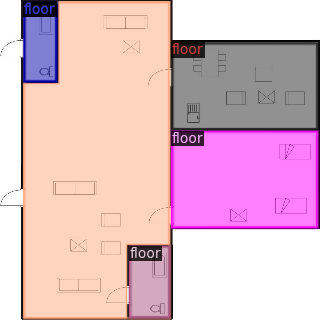

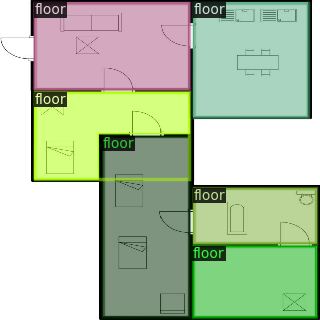

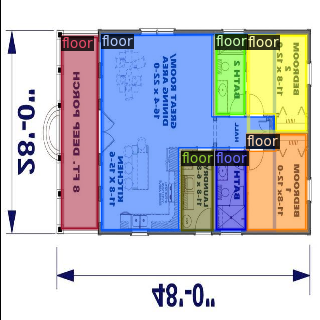

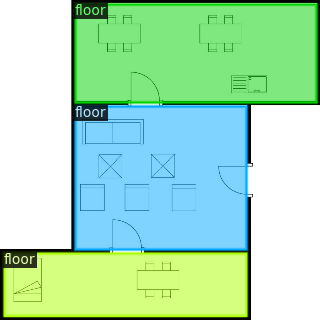

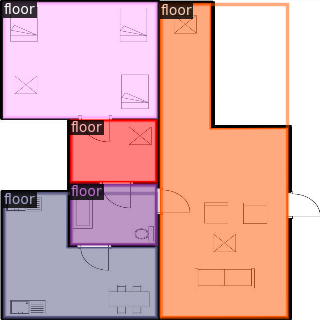

In [13]:
train_metadata = MetadataCatalog.get("exp_train")
dataset_dict = DatasetCatalog.get("exp_train")

for d in random.sample(dataset_dict,5):
  im = cv2.imread(d['file_name'])
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.5
  )
  v = vis.draw_dataset_dict(d)
  cv2_imshow(v.get_image()[:,:,::-1])

- **TRAINING**

In [15]:
cfg = get_cfg()

# Load the Mask R-CNN architecture
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# setup datasets
cfg.DATASETS.TRAIN = ("exp_train",)
cfg.DATASETS.TEST = ("exp_valid",)
cfg.DATALOADER.NUM_WORKERS = 2

# Load pre-trained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Hyperparameter
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0025
cfg.SOLVER.MAX_ITER = 1000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 7

# Initialize trainer
os.makedirs(cfg.OUTPUT_DIR,exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

[09/11 13:05:30 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:02, 72.1MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[09/11 13:05:33 d2.engine.train_loop]: Starting training from iteration 0


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
W0911 13:05:36.435000 4981 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[09/11 13:05:43 d2.utils.events]:  eta: 0:05:24  iter: 19  total_loss: 4.021  loss_cls: 2.159  loss_box_reg: 0.9534  loss_mask: 0.6885  loss_rpn_cls: 0.2234  loss_rpn_loc: 0.03929    time: 0.3414  last_time: 0.3309  data_time: 0.0152  last_data_time: 0.0051   lr: 4.9952e-05  max_mem: 1932M
[09/11 13:05:54 d2.utils.events]:  eta: 0:05:17  iter: 39  total_loss: 2.716  loss_cls: 0.9875  loss_box_reg: 0.9733  loss_mask: 0.5445  loss_rpn_cls: 0.07654  loss_rpn_loc: 0.03185    time: 0.3398  last_time: 0.3867  data_time: 0.0078  last_data_time: 0.0121   lr: 9.9902e-05  max_mem: 1932M
[09/11 13:06:01 d2.utils.events]:  eta: 0:05:11  iter: 59  total_loss: 1.952  loss_cls: 0.5314  loss_box_reg: 0.9298  loss_mask: 0.3946  loss_rpn_cls: 0.02696  loss_rpn_loc: 0.02612    time: 0.3413  last_time: 0.3288  data_time: 0.0077  last_data_time: 0.0071   lr: 0.00014985  max_mem: 1932M
[09/11 13:06:08 d2.utils.events]:  eta: 0:05:06  iter: 79  total_loss: 1.665  loss_cls: 0.3776  loss_box_reg: 0.8398  loss_

- **TESTING**

In [21]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR,"model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("exp_test",)
predictor = DefaultPredictor(cfg)

[09/11 13:16:24 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


- **VISUALIZING RESULT**

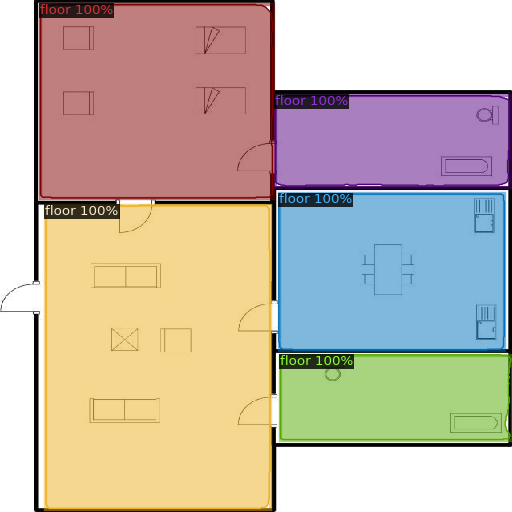

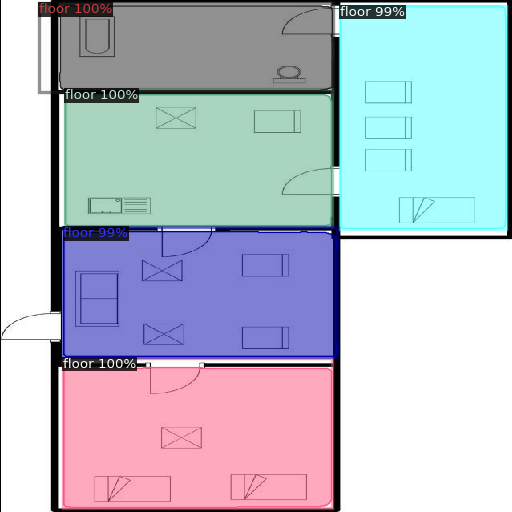

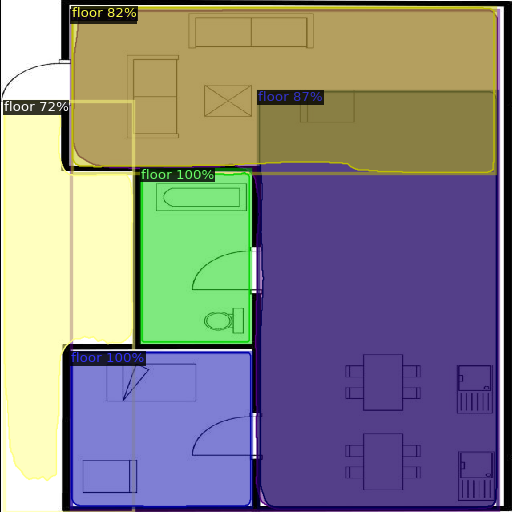

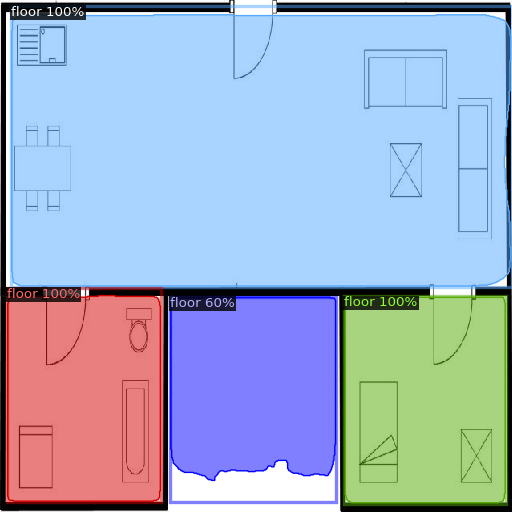

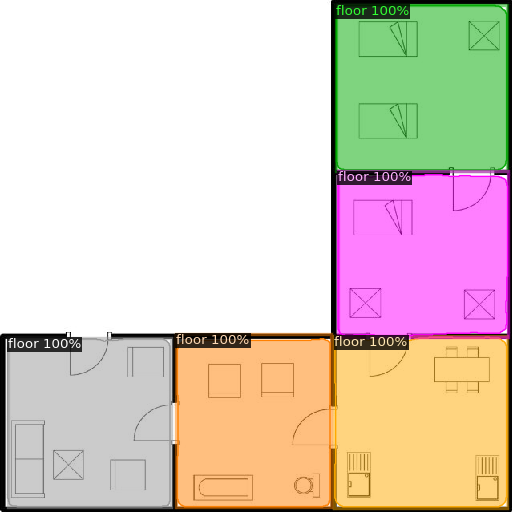

In [24]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,5):
  im =cv2.imread(d['file_name'])
  outputs = predictor(im)
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8
  )
  v = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])

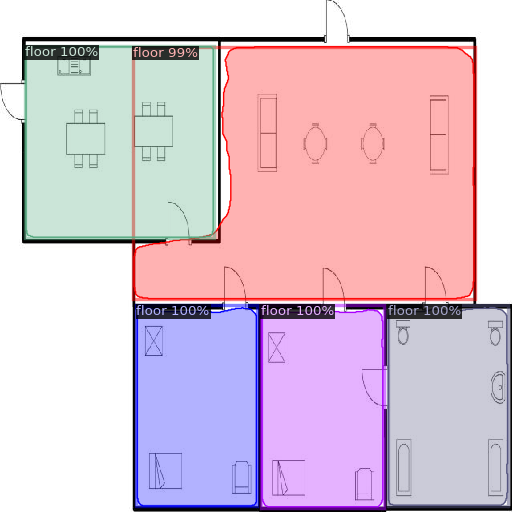

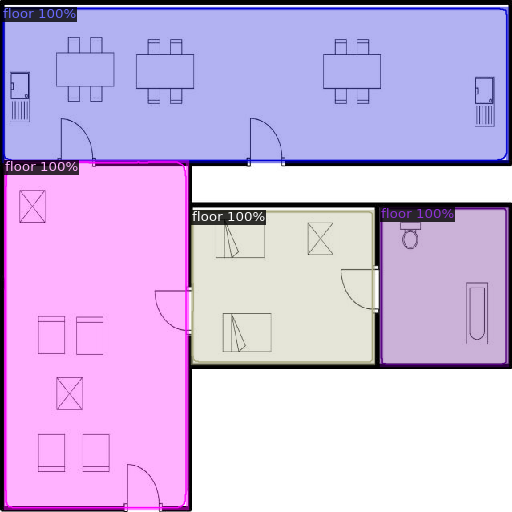

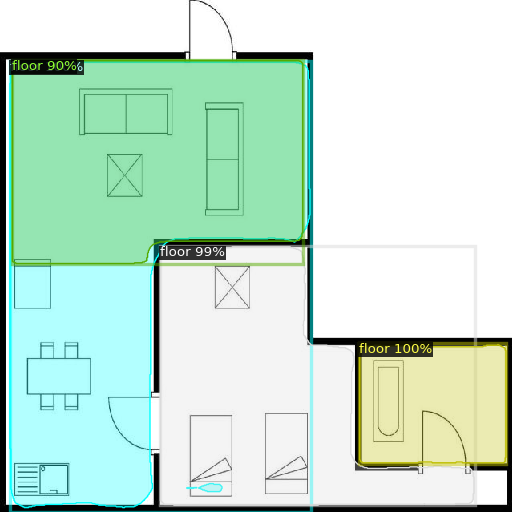

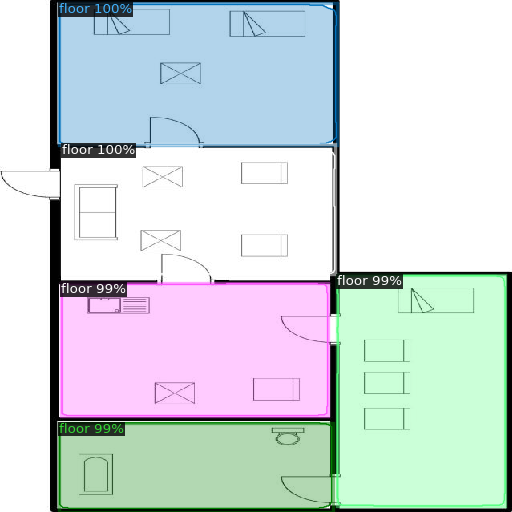

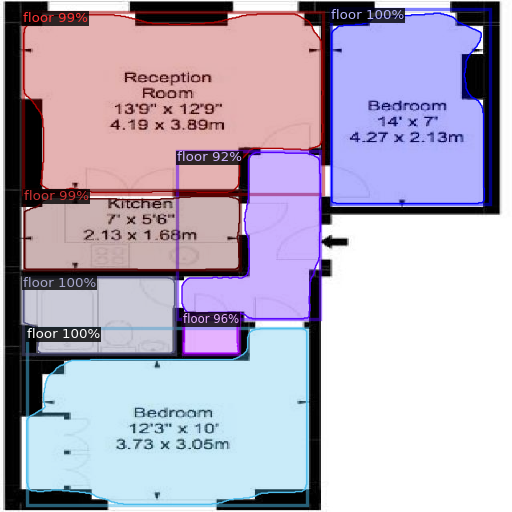

In [25]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,5):
  im =cv2.imread(d['file_name'])
  outputs = predictor(im)
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8,
      instance_mode = ColorMode.IMAGE_BW
  )
  v = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])

- **EVALUATING**

In [ ]:
from detectron2.evaluation import COCOEvaluator,inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("exp_test",)